## 使用Pydantic的好处
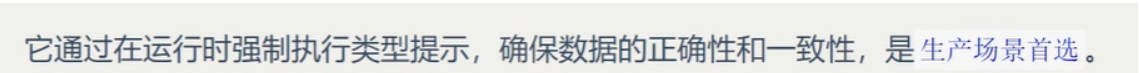 

# # 1.初始化模型
## 注意：ipynb文件里面无法跨文件夹调用文件。

In [2]:
## 1.初始化模型
from langchain.messages import HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field

# 创建模型实例
model = ChatOpenAI(
    model="qwen3-vl:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
    temperature=0.1
)   

In [3]:
class Person(BaseModel):
    """人物信息"""
    name:str = Field(description="姓名")
    age:int = Field(description="年龄")
    job:str = Field(description="职业")

In [ ]:
from rich import print as rprint
# 设置模型输出格式,我们规定它的输出格式位我们的Person类的对象
ret_model = model.with_structured_output(Person)

result = ret_model.invoke("李明是一名30岁的软件工程师")
rprint(result)

Person(name='李明', age=30, job='软件工程师')

In [5]:
print(f"姓名:{result.name},年龄：{result.age},职业：{result.job}")

姓名:李明,年龄：30,职业：软件工程师


In [ ]:
## 1.初始化模型
# from langchain.messages import HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field

# 创建模型实例
model = ChatOpenAI(
    model="qwen3-vl:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
    temperature=0.1
)   

# 定义输出格式
class SentimentAnalysis(BaseModel):
    sentiment: str= Field(description="情感倾向:positive/nagative/neutral")
    confidence: float = Field(description="置信度,0-1之间")
    keywords: list[str]= Field(description="关键词列表")
# 设置模型的输出格式
ret_model = model.with_structured_output(SentimentAnalysis)
txt = "这个课程内容很实用，学到很多知识，强烈推荐!"
result = ret_model.invoke(f"分析以下文本的情感：{txt}")

print(f"类型：{type(result)}")
print(f"情感：{result.sentiment}")
print(f"置信度：{result.confidence}")
print(f"关键词：{result.keywords}")

类型：<class '__main__.SentimentAnalysis'>
情感：<class 'str'>
置信度：<class 'float'>
关键词：<class 'list'>


In [9]:
print(f"类型：{type(result)}")
print(f"情感：{result.sentiment}")
print(f"置信度：{result.confidence}")
print(f"关键词：{result.keywords}")

类型：<class '__main__.SentimentAnalysis'>
情感：positive
置信度：0.95
关键词：['实用', '学到很多知识', '强烈推荐']
